In [1]:
# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2) Load dataset
df = pd.read_csv("/content/Ecommerce_Sales_Data_2024_2025.csv")

In [3]:
# 3) Quick look
display(df.head())

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [4]:
# 4) Shape & columns
print("Shape (rows, cols):", df.shape)
print("\nColumns:\n", df.columns)

Shape (rows, cols): (5000, 14)

Columns:
 Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')


In [5]:
# 5) Info
print("\nInfo:")
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [6]:
# 6) Missing values
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64


In [7]:
# 7) Basic statistics (numeric)
print("\nDescribe (numeric columns):\n", df.describe())


Describe (numeric columns):
            Order ID     Quantity    Unit Price     Discount          Sales  \
count   5000.000000  5000.000000   5000.000000  5000.000000    5000.000000   
mean   12500.500000     2.992600  39760.904600    10.051000  106733.204870   
std     1443.520003     1.413133  22831.783946     7.084662   85108.208202   
min    10001.000000     1.000000    222.000000     0.000000     264.100000   
25%    11250.750000     2.000000  20312.250000     5.000000   39766.537500   
50%    12500.500000     3.000000  39459.500000    10.000000   83080.325000   
75%    13750.250000     4.000000  59721.750000    15.000000  156968.587500   
max    15000.000000     5.000000  79998.000000    20.000000  398485.000000   

             Profit  
count   5000.000000  
mean   15941.746982  
std    14897.684916  
min       19.120000  
25%     4892.295000  
50%    11108.525000  
75%    22467.987500  
max    89688.440000  


In [8]:
# 8) Unique values per column
print("\nNumber of unique values per column:\n", df.nunique())


Number of unique values per column:
 Order ID         5000
Order Date        730
Customer Name    4844
Region              4
City               20
Category           10
Sub-Category       50
Product Name     3835
Quantity            5
Unit Price       4841
Discount            5
Sales            4978
Profit           4996
Payment Mode        5
dtype: int64


In [9]:
# 9) Value counts for main categorical columns (adjust names if needed)
for col in ["Category", "Product", "Country", "ship-state"]:
    if col in df.columns:
        print(f"\nTop values in {col}:")
        print(df[col].value_counts().head())


Top values in Category:
Category
Books         528
Kitchen       528
Furniture     527
Home Decor    515
Sports        511
Name: count, dtype: int64


In [10]:
# 10) GroupBy aggregations (Total Amount by main dimensions) – adjust column names if needed
amount_col = "Amount" if "Amount" in df.columns else ("Sales" if "Sales" in df.columns else None)

if amount_col:
    print(f"\nTotal {amount_col} by Category:")
    if "Category" in df.columns:
        print(df.groupby("Category")[amount_col].sum().sort_values(ascending=False).head(10))

    print(f"\nTotal {amount_col} by Country:")
    if "Country" in df.columns:
        print(df.groupby("Country")[amount_col].sum().sort_values(ascending=False).head(10))

    print(f"\nTotal {amount_col} by ship-state:")
    if "ship-state" in df.columns:
        print(df.groupby("ship-state")[amount_col].sum().sort_values(ascending=False).head(10))


Total Sales by Category:
Category
Home Decor     57233222.35
Furniture      56647187.90
Clothing       55053908.30
Books          54932643.00
Kitchen        54227902.30
Electronics    52587883.95
Toys           52227366.45
Sports         52069397.25
Beauty         50803409.70
Groceries      47883103.15
Name: Sales, dtype: float64

Total Sales by Country:

Total Sales by ship-state:


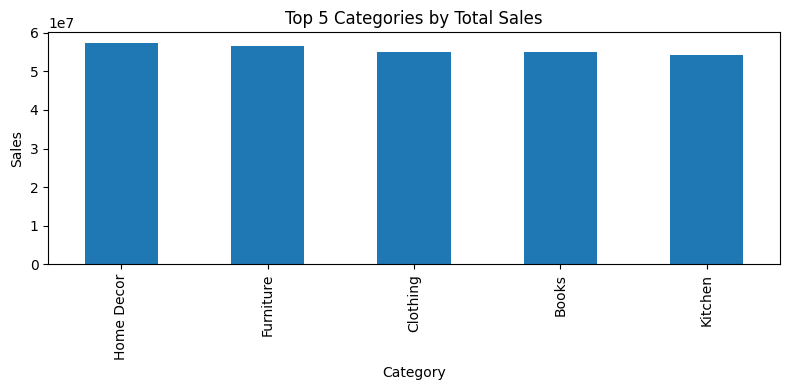

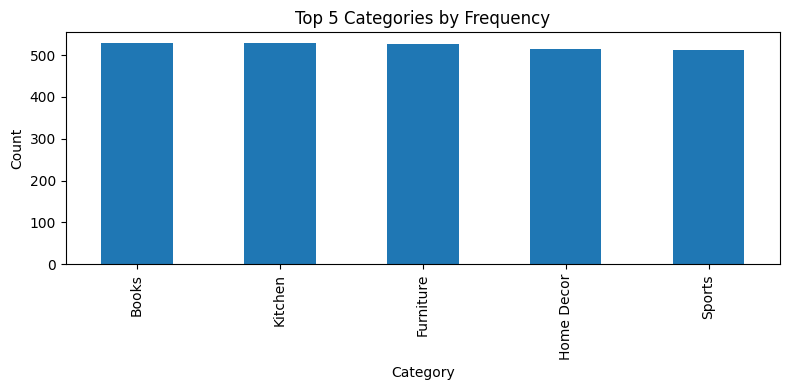

In [11]:
# 11) Simple plots (only if columns exist)
plt.figure(figsize=(8,4))
if amount_col and "Category" in df.columns:
    df.groupby("Category")[amount_col].sum().sort_values(ascending=False).head(5).plot(kind="bar")
    plt.title("Top 5 Categories by Total Sales")
    plt.ylabel(amount_col)
    plt.xlabel("Category")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8,4))
if "Category" in df.columns:
    df["Category"].value_counts().head(5).plot(kind="bar")
    plt.title("Top 5 Categories by Frequency")
    plt.ylabel("Count")
    plt.xlabel("Category")
    plt.tight_layout()
    plt.show()